In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import requests
from requests.adapters import HTTPAdapter

import pybaseball
from pybaseball import statcast, pitching_stats_range, batting_stats_range
pybaseball.cache.enable()

import pybaseballstats.umpire_scorecards as us
import mlbstatsapi as statsapi
import pybaseballstats as pbs

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.calibration import calibration_curve
from xgboost import XGBClassifier

import shap
import joblib

# Load the enhanced dataframes (saved from Cell 8)
model_df = pd.read_csv('model_df.csv')
model_df_log = pd.read_csv('model_df_log.csv')

print("Data loaded. model_df shape:", model_df.shape)
print("Rolling columns present:", [c for c in model_df.columns if 'rolling' in c])

Data loaded. model_df shape: (16224, 40)
Rolling columns present: ['p_rolling_xfip', 'h_rolling_wrc', 'p_rolling_era', 'p_rolling_whip', 'p_rolling_k9', 'p_rolling_hr9', 'h_rolling_ops', 'h_rolling_avg', 'h_rolling_runs']


In [2]:
# -------------------------------------------------------------------
# Cell 2: Download Statcast data from 2022 through today (month-by-month)
# -------------------------------------------------------------------

from datetime import date, datetime, timedelta
import time
import pandas as pd

# Enable caching
pybaseball.cache.enable()

START_DATE = date(2022, 3, 1)
END_DATE = date.today()

def fetch_monthly_statcast(start_dt, end_dt, max_retries=3):
    """Fetch Statcast data for a date range with retries."""
    for attempt in range(max_retries):
        try:
            df = statcast(start_dt, end_dt, verbose=True, parallel=False)
            if df is not None and not df.empty:
                return df
            else:
                print(f"No data for {start_dt} to {end_dt}")
                return pd.DataFrame()
        except Exception as e:
            print(f"Attempt {attempt+1} failed for {start_dt} to {end_dt}: {e}")
            time.sleep(5)  # wait before retry
    print(f"All retries failed for {start_dt} to {end_dt}")
    return pd.DataFrame()

# Generate monthly date ranges
date_ranges = []
current = START_DATE
while current <= END_DATE:
    next_month = current.replace(day=28) + timedelta(days=4)  # skip to next month
    next_month = next_month.replace(day=1)
    end_of_month = min(next_month - timedelta(days=1), END_DATE)
    date_ranges.append((current, end_of_month))
    current = next_month

print(f"Fetching data for {len(date_ranges)} month(s) from {START_DATE} to {END_DATE}")

all_play_data_list = []
for i, (start, end) in enumerate(date_ranges):
    start_str = start.strftime('%Y-%m-%d')
    end_str = end.strftime('%Y-%m-%d')
    print(f"Fetching {i+1}/{len(date_ranges)}: {start_str} to {end_str}")
    df = fetch_monthly_statcast(start_str, end_str)
    if not df.empty:
        all_play_data_list.append(df)
    time.sleep(1)  # polite delay between requests

if all_play_data_list:
    all_play_data = pd.concat(all_play_data_list, ignore_index=True)
    print(f"Total rows downloaded: {len(all_play_data)}")
else:
    all_play_data = pd.DataFrame()
    print("Warning: No data downloaded.")

# Optional: Save a backup CSV (not necessary but useful)
# all_play_data.to_csv('all_play_data_backup.csv', index=False)

Fetching data for 50 month(s) from 2022-03-01 to 2026-04-14
Fetching 1/50: 2022-03-01 to 2022-03-31
This is a large query, it may take a moment to complete
Skipping offseason dates


100%|██████████| 17/17 [00:19<00:00,  1.14s/it]


Fetching 2/50: 2022-04-01 to 2022-04-30
This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:11<00:00,  2.58it/s]


Fetching 3/50: 2022-05-01 to 2022-05-31
This is a large query, it may take a moment to complete


...

Fetching 49/50: 2026-03-01 to 2026-03-31
This is a large query, it may take a moment to complete
Skipping offseason dates


100%|██████████| 17/17 [00:07<00:00,  2.38it/s]


Fetching 50/50: 2026-04-01 to 2026-04-14
This is a large query, it may take a moment to complete


100%|██████████| 14/14 [00:07<00:00,  1.78it/s]


Total rows downloaded: 3191100


In [3]:
# -------------------------------------------------------------------
# Pitcher Times Through the Order Splits
# -------------------------------------------------------------------

# Sort by game, pitcher, batter, and pitch number to ensure order
all_play_data = all_play_data.sort_values(['game_pk', 'pitcher', 'batter', 'pitch_number'])

# Count plate appearances (not pitches) – group by game, pitcher, batter
# Each unique combination of (game_pk, pitcher, batter) represents one PA
all_play_data['pa_counter'] = all_play_data.groupby(['game_pk', 'pitcher', 'batter']).cumcount() + 1

# Label time through order: 1 = first time facing, 2 = second, 3 = third or more
all_play_data['time_through_order'] = np.where(all_play_data['pa_counter'] == 1, 1,
                                       np.where(all_play_data['pa_counter'] == 2, 2, 3))

# Drop temporary column
all_play_data.drop(columns=['pa_counter'], inplace=True)

print("Time through order splits added to all_play_data.")

Time through order splits added to all_play_data.


In [4]:
# -------------------------------------------------------------------
# Calculate xFIP for each pitcher, per game (using Statcast data)
# -------------------------------------------------------------------

# Group by pitcher and game_pk to get per-game totals
pitcher_game_stats = all_play_data.groupby(['pitcher', 'game_pk', 'game_date']).agg(
    SO=('description', lambda x: (x == 'strikeout').sum()),
    BB=('events', lambda x: (x == 'walk').sum()),
    HBP=('events', lambda x: (x == 'hit_by_pitch').sum()),
    HR=('events', lambda x: (x == 'home_run').sum()),
    # Estimate innings pitched: each out counts as 1/3 inning
    outs=('events', lambda x: x.isin(['strikeout', 'field_out', 'grounded_into_double_play',
                                      'fielders_choice_out', 'sac_fly', 'sac_bunt',
                                      'double_play', 'sac_fly_double_play', 'other_out']).sum())
).reset_index()

# Convert outs to innings pitched (IP = outs / 3)
pitcher_game_stats['IP'] = pitcher_game_stats['outs'] / 3

# League FIP constant (2025 approximate; you can update yearly)
league_fip_constant = 3.15

# Calculate xFIP
pitcher_game_stats['xFIP'] = (
    (13 * pitcher_game_stats['HR']) +
    (3 * (pitcher_game_stats['BB'] + pitcher_game_stats['HBP'])) -
    (2 * pitcher_game_stats['SO'])
) / pitcher_game_stats['IP'].replace(0, np.nan) + league_fip_constant

# Replace infinite or missing values with league average xFIP (~4.00)
pitcher_game_stats['xFIP'].replace([np.inf, -np.inf], np.nan, inplace=True)
pitcher_game_stats['xFIP'].fillna(4.00, inplace=True)

print("Pitcher xFIP per game calculated.")

Pitcher xFIP per game calculated.


In [5]:
# -------------------------------------------------------------------
# Calculate wRC+ for each team, per game (using Statcast data)
# -------------------------------------------------------------------

# Linear weights for wOBA (2024 values – adjust if needed)
woba_weights = {
    'single': 0.88,
    'double': 1.25,
    'triple': 1.59,
    'home_run': 2.02,
    'walk': 0.69,
    'hit_by_pitch': 0.69,
    # Outs and other events have negative weight
    'field_out': -0.28,
    'strikeout': -0.28,
    'grounded_into_double_play': -0.28,
    'field_error': -0.28,
    'fielders_choice': -0.28,
    'fielders_choice_out': -0.28,
    'sac_fly': -0.28,
    'sac_bunt': -0.28,
    'double_play': -0.28,
    'sac_fly_double_play': -0.28,
    'other_out': -0.28
}

# Map events to weights
all_play_data['woba_weight'] = all_play_data['events'].map(woba_weights).fillna(0)

# Determine hitting team (same logic as in Cell 4)
all_play_data['hitting_team'] = np.where(
    all_play_data['inning_topbot'] == 'Bot',
    all_play_data['home_team'],
    all_play_data['away_team']
)

# Group by hitting team, game_pk, and game_date
team_game_woba = all_play_data.groupby(['hitting_team', 'game_pk', 'game_date']).agg(
    total_woba=('woba_weight', 'sum'),
    plate_appearances=('events', 'count')
).reset_index()

# Calculate wOBA per game
team_game_woba['wOBA'] = team_game_woba['total_woba'] / team_game_woba['plate_appearances']

# League average wOBA (calculate from your data)
league_avg_woba = team_game_woba['wOBA'].mean()

# Calculate wRC+ (scaled to 100 = league average)
team_game_woba['wRC_plus'] = (team_game_woba['wOBA'] / league_avg_woba) * 100

print("Team wRC+ per game calculated.")

Team wRC+ per game calculated.


In [6]:
# -------------------------------------------------------------------
# Cell 6: First-inning filtering, aggregation, derived stats, and platoon advantage
# -------------------------------------------------------------------

# Subset first inning
fi_2022 = all_play_data[all_play_data['inning'] == 1]

# Keep only last pitch of each at-bat (events not null)
fi_ab_2022 = fi_2022[fi_2022['events'].notnull()]

# Define barrel
fi_ab_2022['barrel'] = fi_ab_2022.apply(
    lambda row: np.nan if pd.isna(row['launch_speed']) or pd.isna(row['launch_angle']) 
    else (1 if row['launch_speed'] > 98.0 and 25.9 <= row['launch_angle'] <= 30.1 else 0),
    axis=1
)

# Create dummies for events
fi_ab_events_2022 = pd.concat([fi_ab_2022, pd.get_dummies(fi_ab_2022['events'])], axis=1)

# Fielding team
fi_ab_events_2022["fielding_team"] = np.where(
    fi_ab_events_2022["inning_topbot"] == "Bot",
    fi_ab_events_2022["away_team"],
    fi_ab_events_2022["home_team"]
)

# ----- Platoon Advantage (added here) -----
fi_ab_events_2022['platoon_advantage'] = np.where(
    ((fi_ab_events_2022['p_throws'] == 'R') & (fi_ab_events_2022['stand'] == 'L')) |
    ((fi_ab_events_2022['p_throws'] == 'L') & (fi_ab_events_2022['stand'] == 'R')),
    1, 0
)

# Group by game and half-inning
grouped = fi_ab_events_2022.groupby(['game_pk', 'inning_topbot'])
fi_grouped_2022 = grouped.agg({
    'game_date': 'first',
    'player_name': 'first',
    'pitcher': 'first',
    'umpire': 'first',
    'home_team': 'first',
    'away_team': 'first',
    'p_throws': 'first',
    'fielding_team': 'first',
    'launch_speed': 'mean',
    'estimated_woba_using_speedangle': 'mean',
    'estimated_ba_using_speedangle': 'mean',
    'home_score': 'max',
    'away_score': 'max',
    'delta_run_exp': 'sum',
    'strikeout': 'sum',
    'grounded_into_double_play': 'sum',
    'single': 'sum',
    'double': 'sum',
    'triple': 'sum',
    'home_run': 'sum',
    'walk': 'sum',
    'field_out': 'sum',
    'fielders_choice_out': 'sum',
    'hit_by_pitch': 'sum',
    'sac_fly': 'sum',
    'field_error': 'sum',
    'catcher_interf': 'sum',
    'fielders_choice': 'sum',
    'double_play': 'sum',
    'sac_bunt': 'sum',
    'sac_fly_double_play': 'sum',
    'barrel': 'mean',
    'platoon_advantage': 'mean'   # <-- added here
}).reset_index()

# Hitting team and runs scored
fi_grouped_2022["hitting_team"] = np.where(
    fi_grouped_2022["inning_topbot"] == "Bot",
    fi_grouped_2022["home_team"],
    fi_grouped_2022["away_team"]
)
fi_grouped_2022["hitting_runs"] = np.where(
    fi_grouped_2022["inning_topbot"] == "Bot",
    fi_grouped_2022["home_score"],
    fi_grouped_2022["away_score"]
)

# ----- Derived stats (needed for rolling averages) -----
fi_grouped_2022['hits'] = (fi_grouped_2022['single'] + fi_grouped_2022['double'] +
                           fi_grouped_2022['triple'] + fi_grouped_2022['home_run'])
fi_grouped_2022['outs'] = (fi_grouped_2022['strikeout'] + fi_grouped_2022['grounded_into_double_play'] +
                           fi_grouped_2022['field_out'] + fi_grouped_2022['fielders_choice_out'] +
                           fi_grouped_2022['field_error'] + fi_grouped_2022['fielders_choice'] +
                           fi_grouped_2022['double_play'] + fi_grouped_2022['sac_fly_double_play'])
fi_grouped_2022['walks'] = fi_grouped_2022['walk'] + fi_grouped_2022['hit_by_pitch']

fi_grouped_2022['avg'] = fi_grouped_2022['hits'] / (fi_grouped_2022['hits'] + fi_grouped_2022['outs'] + 1e-6)
fi_grouped_2022['era'] = fi_grouped_2022['hitting_runs'] * 9
fi_grouped_2022['slg'] = (fi_grouped_2022['single'] + 2*fi_grouped_2022['double'] + 3*fi_grouped_2022['triple'] + 4*fi_grouped_2022['home_run']) / (fi_grouped_2022['hits'] + fi_grouped_2022['outs'] + 1e-6)
fi_grouped_2022['obp'] = (fi_grouped_2022['hits'] + fi_grouped_2022['walks']) / (fi_grouped_2022['hits'] + fi_grouped_2022['walks'] + fi_grouped_2022['outs'] + 1e-6)
fi_grouped_2022['ops'] = fi_grouped_2022['slg'] + fi_grouped_2022['obp']
fi_grouped_2022['whip'] = fi_grouped_2022['hits'] + fi_grouped_2022['walks']
fi_grouped_2022['games_played'] = 1
fi_grouped_2022['hr9'] = (fi_grouped_2022['home_run'] / fi_grouped_2022['games_played']) * 9

print("Cell 6 finished. fi_grouped_2022 shape:", fi_grouped_2022.shape)


Cell 6 finished. fi_grouped_2022 shape: (22064, 48)


In [7]:
# -------------------------------------------------------------------
# Merge advanced metrics (xFIP, wRC+) into fi_grouped_2022
# -------------------------------------------------------------------

# Merge pitcher xFIP (using pitcher ID and game_pk)
fi_grouped_2022 = fi_grouped_2022.merge(
    pitcher_game_stats[['pitcher', 'game_pk', 'xFIP']],
    on=['pitcher', 'game_pk'],
    how='left'
)

# Merge team wRC+ (using hitting_team and game_pk)
fi_grouped_2022 = fi_grouped_2022.merge(
    team_game_woba[['hitting_team', 'game_pk', 'wRC_plus']],
    on=['hitting_team', 'game_pk'],
    how='left'
)

# Fill missing values with league averages
fi_grouped_2022['xFIP'].fillna(4.00, inplace=True)
fi_grouped_2022['wRC_plus'].fillna(100, inplace=True)

print("Advanced metrics (xFIP, wRC+) merged into fi_grouped_2022.")

Advanced metrics (xFIP, wRC+) merged into fi_grouped_2022.


In [8]:
# -------------------------------------------------------------------
# Efficient Umpire Strike Zone Data (Called Strike Rate)
# -------------------------------------------------------------------

from pybaseballstats import umpire_scorecards as us
from datetime import timedelta

print("Fetching umpire data for the entire date range...")

# Fetch all umpire scorecard data once
try:
    umpire_data_polars = us.game_data(START_DATE.strftime('%Y-%m-%d'), END_DATE.strftime('%Y-%m-%d'))
    umpire_data = umpire_data_polars.to_pandas()
    print(f"Fetched {len(umpire_data)} umpire game records.")
except Exception as e:
    print(f"Error fetching umpire data: {e}")
    # If fetch fails, create an empty dataframe with required columns
    umpire_data = pd.DataFrame(columns=['Date', 'Umpire', 'Called Strike Rate'])

# Rename columns to match our merge keys
if not umpire_data.empty:
    # Adjust column names based on actual output; common names are 'Date', 'Umpire', 'Called Strike Rate'
    umpire_data.rename(columns={
        'Date': 'game_date',
        'Umpire': 'umpire',
        'Called Strike Rate': 'umpire_strike_rate'
    }, inplace=True)
    # Ensure game_date is datetime
    umpire_data['game_date'] = pd.to_datetime(umpire_data['game_date'])

    # Merge into fi_grouped_2022
    fi_grouped_2022 = fi_grouped_2022.merge(
        umpire_data[['game_date', 'umpire', 'umpire_strike_rate']],
        on=['game_date', 'umpire'],
        how='left'
    )
else:
    # If no data, create column with NaNs
    fi_grouped_2022['umpire_strike_rate'] = np.nan

# Fill missing values with league average called strike rate (~0.630)
fi_grouped_2022['umpire_strike_rate'].fillna(0.630, inplace=True)

print("Umpire strike rate added. Missing values filled with league average (0.630).")

Fetching umpire data for the entire date range...
Error fetching umpire data: could not append value: 0 of type: i64 to the builder; make sure that all rows have the same schema or consider increasing `infer_schema_length`

it might also be that a value overflows the data-type's capacity
Umpire strike rate added. Missing values filled with league average (0.630).


In [9]:
# -------------------------------------------------------------------
# Team 1st Inning Scoring % (rolling 5 games)
# -------------------------------------------------------------------

# Create binary indicator: 1 if team scored in first inning, else 0
fi_grouped_2022['team_scored'] = (fi_grouped_2022['hitting_runs'] > 0).astype(int)

# Sort by team and date
fi_grouped_2022 = fi_grouped_2022.sort_values(['hitting_team', 'game_date'])

# Rolling percentage (last 5 games, excluding current)
fi_grouped_2022['team_1st_inning_score_pct'] = (
    fi_grouped_2022.groupby('hitting_team')['team_scored']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Fill missing (first few games) with league average (~0.286)
fi_grouped_2022['team_1st_inning_score_pct'].fillna(0.286, inplace=True)

# Drop temporary column
fi_grouped_2022.drop(columns=['team_scored'], inplace=True)

print("Team 1st inning scoring % added.")

Team 1st inning scoring % added.


In [10]:
# -------------------------------------------------------------------
# Rolling Averages for Advanced Metrics (xFIP & wRC+)
# -------------------------------------------------------------------

# Ensure we have a clean integer index
fi_grouped_2022 = fi_grouped_2022.reset_index(drop=True)
fi_grouped_2022['game_date'] = pd.to_datetime(fi_grouped_2022['game_date'])

# Pitcher rolling xFIP (use actual column 'xFIP')
fi_grouped_2022 = fi_grouped_2022.sort_values(['pitcher', 'game_date']).reset_index(drop=True)
fi_grouped_2022['p_rolling_xfip'] = (
    fi_grouped_2022.groupby('pitcher')['xFIP']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Team hitting rolling wRC+ (use actual column 'wRC_plus')
fi_grouped_2022 = fi_grouped_2022.sort_values(['hitting_team', 'game_date']).reset_index(drop=True)
fi_grouped_2022['h_rolling_wrc'] = (
    fi_grouped_2022.groupby('hitting_team')['wRC_plus']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)

# Fill missing values (first appearance) with column mean
fi_grouped_2022['p_rolling_xfip'].fillna(fi_grouped_2022['p_rolling_xfip'].mean(), inplace=True)
fi_grouped_2022['h_rolling_wrc'].fillna(fi_grouped_2022['h_rolling_wrc'].mean(), inplace=True)

print("Rolling averages for advanced metrics added.")

Rolling averages for advanced metrics added.


In [11]:
# -------------------------------------------------------------------
# Rolling averages (last 3 games) – add to fi_grouped_2022
# -------------------------------------------------------------------

# Ensure we have a clean integer index
fi_grouped_2022 = fi_grouped_2022.reset_index(drop=True)
fi_grouped_2022['game_date'] = pd.to_datetime(fi_grouped_2022['game_date'])

# Helper function for rolling stats (using transform)
def rolling_shift_mean(group_series, window=3):
    return group_series.shift(1).rolling(window, min_periods=1).mean()

# Pitcher rolling stats
fi_grouped_2022 = fi_grouped_2022.sort_values(['pitcher', 'game_date']).reset_index(drop=True)
fi_grouped_2022['p_rolling_era'] = fi_grouped_2022.groupby('pitcher')['era'].transform(rolling_shift_mean)
fi_grouped_2022['p_rolling_whip'] = fi_grouped_2022.groupby('pitcher')['whip'].transform(rolling_shift_mean)
fi_grouped_2022['p_rolling_k9'] = fi_grouped_2022.groupby('pitcher')['strikeout'].transform(rolling_shift_mean)
fi_grouped_2022['p_rolling_hr9'] = fi_grouped_2022.groupby('pitcher')['home_run'].transform(rolling_shift_mean)

# Team hitting rolling stats
fi_grouped_2022 = fi_grouped_2022.sort_values(['hitting_team', 'game_date']).reset_index(drop=True)
fi_grouped_2022['h_rolling_ops'] = fi_grouped_2022.groupby('hitting_team')['ops'].transform(rolling_shift_mean)
fi_grouped_2022['h_rolling_avg'] = fi_grouped_2022.groupby('hitting_team')['avg'].transform(rolling_shift_mean)
fi_grouped_2022['h_rolling_runs'] = fi_grouped_2022.groupby('hitting_team')['hitting_runs'].transform(rolling_shift_mean)

# Fill missing values (first appearance) with column mean
for col in ['p_rolling_era', 'p_rolling_whip', 'p_rolling_k9', 'p_rolling_hr9',
            'h_rolling_ops', 'h_rolling_avg', 'h_rolling_runs']:
    fi_grouped_2022[col].fillna(fi_grouped_2022[col].mean(), inplace=True)

print("Rolling averages added. New rolling columns:", [c for c in fi_grouped_2022.columns if 'rolling' in c])

Rolling averages added. New rolling columns: ['p_rolling_xfip', 'h_rolling_wrc', 'p_rolling_era', 'p_rolling_whip', 'p_rolling_k9', 'p_rolling_hr9', 'h_rolling_ops', 'h_rolling_avg', 'h_rolling_runs']


In [12]:
# -------------------------------------------------------------------
# Feature engineering: Pitcher NRFI Rate & Travel Fatigue
# -------------------------------------------------------------------

# Ensure fi_grouped_2022 exists
if 'fi_grouped_2022' not in globals():
    raise NameError("fi_grouped_2022 not found. Run Cell 4 first.")

# ----- Pitcher NRFI Rate -----
fi_grouped_2022['pitcher_nrfi_success'] = (fi_grouped_2022['hitting_runs'] == 0).astype(int)
fi_grouped_2022 = fi_grouped_2022.sort_values(['pitcher', 'game_date'])
fi_grouped_2022['pitcher_nrfi_rate'] = (
    fi_grouped_2022.groupby('pitcher')['pitcher_nrfi_success']
    .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
)
fi_grouped_2022['pitcher_nrfi_rate'].fillna(0.714, inplace=True)  # league average

# ----- Travel Fatigue (simplified) -----
# For each team, find the location of their previous game
fi_grouped_2022 = fi_grouped_2022.sort_values(['hitting_team', 'game_date'])
fi_grouped_2022['prev_home_team'] = fi_grouped_2022.groupby('hitting_team')['home_team'].shift(1)
# Binary flag: 1 if the team played away from their current home stadium in the previous game
fi_grouped_2022['travel_fatigue'] = (fi_grouped_2022['hitting_team'] != fi_grouped_2022['prev_home_team']).astype(int)
fi_grouped_2022['travel_fatigue'].fillna(0, inplace=True)

print("Added features: pitcher_nrfi_rate, travel_fatigue")

Added features: pitcher_nrfi_rate, travel_fatigue


In [13]:
# =============================================================================
# Cell 12: Aggregate pitcher-level stats from half-inning data
# =============================================================================

groupsp = fi_grouped_2022.groupby(['player_name'])

pitchers1 = groupsp.agg({
    'pitcher_nrfi_rate': 'first',
    'fielding_team': 'first',
    'launch_speed': 'mean',
    'estimated_woba_using_speedangle': 'mean',
    'estimated_ba_using_speedangle': 'mean',
    'delta_run_exp': 'sum',
    'strikeout': 'mean',
    'avg': 'mean',
    'era': 'mean',
    'slg': 'mean',
    'ops': 'mean',
    'whip': 'mean',
    'hitting_runs': 'sum',
    'games_played': 'sum',
    'hr9': 'mean',
    'barrel': 'mean'
}).reset_index()

# Add p_ prefix to all columns except 'player_name'
pitchers1.rename(columns={
    'fielding_team': 'p_fielding_team',
    'launch_speed': 'p_launch_speed',
    'estimated_woba_using_speedangle': 'p_estimated_woba_using_speedangle',
    'estimated_ba_using_speedangle': 'p_estimated_ba_using_speedangle',
    'delta_run_exp': 'p_delta_run_exp',
    'strikeout': 'p_strikeout',
    'avg': 'p_avg',
    'era': 'p_era',
    'slg': 'p_slg',
    'ops': 'p_ops',
    'whip': 'p_whip',
    'hitting_runs': 'p_hitting_runs',
    'games_played': 'p_games_played',
    'hr9': 'p_hr9',
    'barrel': 'p_barrel'
}, inplace=True)

print(f"pitchers1 built: {pitchers1.shape[0]} pitchers")

pitchers1 built: 887 pitchers


In [14]:
# =============================================================================
# Cell 7: Aggregate team hitting stats from half-inning data
# =============================================================================

groupsh = fi_grouped_2022.groupby(['hitting_team'])

hitters1 = groupsh.agg({
    'launch_speed': 'mean',
    'estimated_woba_using_speedangle': 'mean',
    'estimated_ba_using_speedangle': 'mean',
    'delta_run_exp': 'sum',
    'strikeout': 'mean',
    'avg': 'mean',
    'slg': 'mean',
    'ops': 'mean',
    'hitting_runs': 'sum',
    'games_played': 'sum',
    'hitting_runs': 'mean',          # becomes h_avg_runs
    'barrel': 'mean'
  }).reset_index()

hitters1.rename(columns={
    'launch_speed': 'h_launch_speed',
    'estimated_woba_using_speedangle': 'h_estimated_woba_using_speedangle',
    'estimated_ba_using_speedangle': 'h_estimated_ba_using_speedangle',
    'delta_run_exp': 'h_delta_run_exp',
    'strikeout': 'h_strikeout',
    'avg': 'h_avg',
    'slg': 'h_slg',
    'ops': 'h_ops',
    'hitting_runs': 'h_avg_runs',
    'games_played': 'h_games_played',
    'barrel': 'h_barrel'
}, inplace=True)

print(f"hitters1 built: {hitters1.shape[0]} teams")

hitters1 built: 30 teams


In [15]:
def get_top3_woba(game_date, hitting_team):
    try:
        schedule = statsapi.schedule(date=game_date.strftime('%Y-%m-%d'), team=hitting_team)
        if not schedule:
            return None
        game_pk = schedule[0]['game_id']
        lineup = statsapi.lineup(game_pk)
        team_lineup = None
        for team in lineup:
            if team['teamAbbrev'] == hitting_team:
                team_lineup = team['lineup']
                break
        if not team_lineup or len(team_lineup) < 3:
            return None
        top3_ids = [player['personId'] for player in team_lineup[:3]]
        start_date = (game_date - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
        end_date = game_date.strftime('%Y-%m-%d')
        woba_data = batting_stats_range(start_date, end_date, qual=10)
        woba_data = woba_data[['player_id', 'wOBA']].dropna()
        woba_values = []
        for player_id in top3_ids:
            player_woba = woba_data[woba_data['player_id'] == player_id]['wOBA']
            if not player_woba.empty:
                woba_values.append(player_woba.iloc[0])
            else:
                woba_values.append(0.300)
        return np.mean(woba_values)
    except Exception:
        return None

In [16]:
print("Calculating Top 3 wOBA...")
fi_grouped_2022['top3_woba'] = fi_grouped_2022.apply(
    lambda row: get_top3_woba(row['game_date'], row['hitting_team']), axis=1
)
fi_grouped_2022['top3_woba'].fillna(fi_grouped_2022['top3_woba'].mean(), inplace=True)

Calculating Top 3 wOBA...


0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
22059    NaN
22060    NaN
22061    NaN
22062    NaN
22063    NaN
Name: top3_woba, Length: 22064, dtype: object

In [17]:
def get_umpire_called_strike_rate(umpire_name, game_date):
    try:
        end_date = game_date.strftime('%Y-%m-%d')
        start_date = (game_date - pd.Timedelta(days=30)).strftime('%Y-%m-%d')
        ump_stats = pbs.umpire_stats(start_date=start_date, end_date=end_date)
        ump_data = ump_stats[ump_stats['umpire'] == umpire_name]
        if ump_data.empty:
            return 0.630
        total_called = ump_data['called_pitch_count'].sum()
        strikes_called = ump_data['called_strike_count'].sum()
        return strikes_called / total_called if total_called > 0 else 0.630
    except Exception:
        return 0.630

In [18]:
print("Calculating Umpire Called Strike Rate...")
fi_grouped_2022['umpire_called_strike_rate'] = fi_grouped_2022.apply(
    lambda row: get_umpire_called_strike_rate(row['umpire'], row['game_date']), axis=1
)
fi_grouped_2022['umpire_called_strike_rate'].fillna(0.630, inplace=True)

Calculating Umpire Called Strike Rate...


0        0.63
1        0.63
2        0.63
3        0.63
4        0.63
         ... 
22059    0.63
22060    0.63
22061    0.63
22062    0.63
22063    0.63
Name: umpire_called_strike_rate, Length: 22064, dtype: float64

In [19]:
# Pitcher rest days (days since last start)
fi_grouped_2022 = fi_grouped_2022.sort_values(['pitcher', 'game_date'])
fi_grouped_2022['prev_game_date'] = fi_grouped_2022.groupby('pitcher')['game_date'].shift(1)
fi_grouped_2022['rest_days'] = (fi_grouped_2022['game_date'] - fi_grouped_2022['prev_game_date']).dt.days
# First appearance: fill with median (typically 5 days)
fi_grouped_2022['rest_days'].fillna(5, inplace=True)
# Cap at 10 days (extra rest has diminishing returns)
fi_grouped_2022['rest_days'] = fi_grouped_2022['rest_days'].clip(upper=10)

In [20]:
# Run this in a new cell
!pip install timezonefinder

import timezonefinder
import pytz
from datetime import datetime

In [21]:
# Stadium coordinates (latitude, longitude) for all 30 MLB teams
stadium_coords = {
    'ARI': (33.4454, -112.0668), 'ATL': (33.8903, -84.4681), 'BAL': (39.2839, -76.6216),
    'BOS': (42.3467, -71.0972), 'CHC': (41.9484, -87.6553), 'CHW': (41.8300, -87.6339),
    'CIN': (39.0974, -84.5068), 'CLE': (41.4960, -81.6852), 'COL': (39.7562, -104.9943),
    'DET': (42.3393, -83.0487), 'HOU': (29.7569, -95.3556), 'KCR': (39.0515, -94.4808),
    'LAA': (33.8003, -117.8826), 'LAD': (34.0736, -118.2400), 'MIA': (25.7781, -80.2198),
    'MIL': (43.0284, -87.9712), 'MIN': (44.9816, -93.2775), 'NYM': (40.7571, -73.8458),
    'NYY': (40.8296, -73.9262), 'OAK': (37.7516, -122.2006), 'PHI': (39.9056, -75.1665),
    'PIT': (40.4468, -80.0058), 'SDP': (32.7077, -117.1571), 'SEA': (47.5914, -122.3329),
    'SFG': (37.7784, -122.3892), 'STL': (38.6226, -90.1928), 'TBR': (27.7682, -82.6532),
    'TEX': (32.7513, -97.0825), 'TOR': (43.6414, -79.3891), 'WSN': (38.8729, -77.0075),
}  
print("Stadium coordinates loaded for", len(stadium_coords), "teams.")

Stadium coordinates loaded for 30 teams.


In [22]:
import time
import requests

def get_game_weather(game_date, team_abbr, game_hour=19):
    """
    Fetch weather data for a specific game date, stadium, and hour.
    Returns None if data not available.
    """
    if team_abbr not in stadium_coords:
        return None
    lat, lon = stadium_coords[team_abbr]
    
    if hasattr(game_date, 'strftime'):
        date_str = game_date.strftime('%Y-%m-%d')
    else:
        date_str = str(game_date)
    
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': date_str,
        'end_date': date_str,
        'hourly': ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'precipitation'],
        'timezone': 'auto'
    }
    
    try:
        time.sleep(0.2)  # Small delay to be respectful to the free API
        response = requests.get(url, params=params, timeout=10)
        response.raise_for_status()
        data = response.json()
        
        if 'hourly' in data and data['hourly']['time']:
            times = data['hourly']['time']
            target_hour_str = f"{date_str}T{game_hour:02d}:00"
            if target_hour_str in times:
                idx = times.index(target_hour_str)
                return {
                    'temperature': data['hourly']['temperature_2m'][idx],
                    'humidity': data['hourly']['relative_humidity_2m'][idx],
                    'wind_speed': data['hourly']['wind_speed_10m'][idx],
                    'precipitation': data['hourly']['precipitation'][idx]
                }
        return None
    except Exception as e:
        return None

print("✅ Weather function defined. Ready to run Cell 7 (weather fetch).")

✅ Weather function defined. Ready to run Cell 7 (weather fetch).


In [23]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import os
from datetime import date, datetime

weather_cache_file = 'weather_cache.csv'

if os.path.exists(weather_cache_file):
    print("Loading cached weather data...")
    weather_cache = pd.read_csv(weather_cache_file)
    # Convert game_date in cache to datetime
    weather_cache['game_date'] = pd.to_datetime(weather_cache['game_date'])
    
    # Ensure fi_grouped_2022 has weather columns initialized
    for col in ['temperature', 'humidity', 'wind_speed', 'precipitation']:
        if col not in fi_grouped_2022.columns:
            fi_grouped_2022[col] = np.nan
    
    # Merge on datetime columns (both are now datetime)
    fi_grouped_2022 = fi_grouped_2022.merge(
        weather_cache[['game_date', 'home_team', 'temperature', 'humidity', 'wind_speed', 'precipitation']],
        on=['game_date', 'home_team'],
        how='left',
        suffixes=('', '_cached')
    )
    # Overwrite original columns with cached values where available
    for col in ['temperature', 'humidity', 'wind_speed', 'precipitation']:
        cached_col = f'{col}_cached'
        if cached_col in fi_grouped_2022.columns:
            # Use cached value where original is NaN
            fi_grouped_2022[col] = fi_grouped_2022[col].fillna(fi_grouped_2022[cached_col])
            fi_grouped_2022.drop(columns=[cached_col], inplace=True)
    print("Weather data loaded from cache.")
else:
    print("Fetching weather data in parallel (3 threads)...")
    
    # Initialize weather columns
    for col in ['temperature', 'humidity', 'wind_speed', 'precipitation']:
        if col not in fi_grouped_2022.columns:
            fi_grouped_2022[col] = np.nan
    
    unique_games = fi_grouped_2022[['game_date', 'home_team']].drop_duplicates().reset_index(drop=True)
    today = date.today()
    
    def fetch_one(game_date, home_team):
        if isinstance(game_date, (date, datetime)):
            if game_date.date() > today:
                return None
        elif isinstance(game_date, str):
            if game_date > str(today):
                return None
        weather = get_game_weather(game_date, home_team, game_hour=19)
        if weather is None:
            weather = get_game_weather(game_date, home_team, game_hour=12)
        return weather
    
    cache_records = []
    success_count = 0
    skip_count = 0
    total = len(unique_games)
    
    with ThreadPoolExecutor(max_workers=3) as executor:
        future_to_game = {}
        for idx, row in unique_games.iterrows():
            future = executor.submit(fetch_one, row['game_date'], row['home_team'])
            future_to_game[future] = (row['game_date'], row['home_team'])
        
        for i, future in enumerate(as_completed(future_to_game)):
            game_date, home_team = future_to_game[future]
            weather = future.result()
            
            if weather:
                mask = (fi_grouped_2022['game_date'] == game_date) & (fi_grouped_2022['home_team'] == home_team)
                fi_grouped_2022.loc[mask, 'temperature'] = weather['temperature']
                fi_grouped_2022.loc[mask, 'humidity'] = weather['humidity']
                fi_grouped_2022.loc[mask, 'wind_speed'] = weather['wind_speed']
                fi_grouped_2022.loc[mask, 'precipitation'] = weather['precipitation']
                success_count += 1
                cache_records.append({
                    'game_date': game_date,
                    'home_team': home_team,
                    'temperature': weather['temperature'],
                    'humidity': weather['humidity'],
                    'wind_speed': weather['wind_speed'],
                    'precipitation': weather['precipitation']
                })
            else:
                skip_count += 1
            
            if (i+1) % 50 == 0:
                print(f"Processed {i+1}/{total} games. Success: {success_count}, Skipped: {skip_count}")
    
    if cache_records:
        cache_df = pd.DataFrame(cache_records)
        cache_df.to_csv(weather_cache_file, index=False)
        print(f"Saved {len(cache_records)} weather records to {weather_cache_file}")
    
    print(f"Weather fetch complete. Success: {success_count}, Skipped (future dates): {skip_count}")

Loading cached weather data...
Weather data loaded from cache.


In [24]:
# Fetch park factors directly from Baseball Savant (2023-2025 average)
import requests
import pandas as pd

# We'll manually input the 3-year average park factors (2023-2025) for each team
# Based on Statcast data as of April 2025. If you have exact numbers, replace these.
# These are approximate values (100 = neutral). You can update later.
park_factors_dict = {
    'ARI': 98, 'ATL': 102, 'BAL': 99, 'BOS': 105, 'CHC': 101,
    'CHW': 97, 'CIN': 106, 'CLE': 95, 'COL': 112, 'DET': 96,
    'HOU': 100, 'KCR': 99, 'LAA': 101, 'LAD': 101, 'MIA': 95,
    'MIL': 99, 'MIN': 99, 'NYM': 98, 'NYY': 104, 'OAK': 94,
    'PHI': 102, 'PIT': 97, 'SDP': 97, 'SEA': 95, 'SFG': 96,
    'STL': 99, 'TBR': 96, 'TEX': 103, 'TOR': 100, 'WSN': 99,
}

# Convert to DataFrame
pf_df = pd.DataFrame(list(park_factors_dict.items()), columns=['home_team', 'park_factor'])

# Save to Excel
with pd.ExcelWriter('NRFI.xlsx') as writer:
    pf_df.to_excel(writer, sheet_name='PF', index=False)

print("NRFI.xlsx created with 3-year average park factors.")

NRFI.xlsx created with 3-year average park factors.


In [25]:
# Cell 7.5: Load park factors
try:
    xls = pd.ExcelFile('NRFI.xlsx')
    pf = pd.read_excel(xls, 'PF')
    pf = pf.iloc[:, 0:2]  # home_team, park_factor
    print("Park factors loaded from NRFI.xlsx")
except FileNotFoundError:
    # Fallback: create from dictionary (in case file is missing)
    park_factors_dict = {
        'ARI': 98, 'ATL': 102, 'BAL': 99, 'BOS': 105, 'CHC': 101,
        'CHW': 97, 'CIN': 106, 'CLE': 95, 'COL': 112, 'DET': 96,
        'HOU': 100, 'KCR': 99, 'LAA': 101, 'LAD': 101, 'MIA': 95,
        'MIL': 99, 'MIN': 99, 'NYM': 98, 'NYY': 104, 'OAK': 94,
        'PHI': 102, 'PIT': 97, 'SDP': 97, 'SEA': 95, 'SFG': 96,
        'STL': 99, 'TBR': 96, 'TEX': 103, 'TOR': 100, 'WSN': 99,
    }
    pf = pd.DataFrame(list(park_factors_dict.items()), columns=['home_team', 'park_factor'])
    print("Park factors created from dictionary.")

Park factors loaded from NRFI.xlsx


In [26]:
# -------------------------------------------------------------------
# Cell 8: Final Data Preparation with All Features (no duplicates)
# -------------------------------------------------------------------

# 1. Merge park factors
for col in ['park_factor', 'park_factor_x', 'park_factor_y']:
    if col in fi_grouped_2022.columns:
        fi_grouped_2022 = fi_grouped_2022.drop(columns=[col])
fi_grouped_2022 = pd.merge(fi_grouped_2022, pf, on='home_team', suffixes=('', '_pf'))

# 2. Merge pitcher stats (pitchers1) and hitter stats (hitters1)
df1 = pd.merge(fi_grouped_2022, pitchers1, on='player_name', suffixes=('', '_p'))
df = pd.merge(df1, hitters1, on='hitting_team', suffixes=('', '_h'))

# 3. Remove duplicate column names (keep first occurrence)
df = df.loc[:, ~df.columns.duplicated()]

# 4. Create binary target
df['run_first_inning_yes'] = np.where(df['hitting_runs'] > 0, 1, 0)

# 5. Define base features (adjust as needed)
base_features = [
    'park_factor',
    'p_strikeout', 'p_barrel', 'p_era', 'p_launch_speed',
    'p_estimated_woba_using_speedangle', 'p_estimated_ba_using_speedangle',
    'p_hr9', 'p_whip', 'p_ops', 'p_games_played',
    'h_avg_runs', 'h_strikeout', 'h_launch_speed', 'h_barrel',
    'h_estimated_woba_using_speedangle', 'h_estimated_ba_using_speedangle', 'h_ops',
    'rest_days', 'travel_fatigue','pitcher_nrfi_rate',
    'temperature', 'humidity', 'wind_speed', 'precipitation',
    'top3_woba', 'umpire_called_strike_rate','platoon_advantage',
    'p_rolling_xfip', 'h_rolling_wrc',
    'time_through_order', 'team_1st_inning_score_pct'
]

# 6. Add rolling features if any
rolling_features = [c for c in df.columns if 'rolling' in c]
all_features = base_features + rolling_features + ['hitting_runs', 'run_first_inning_yes']

# Keep only existing columns
existing_features = [c for c in all_features if c in df.columns]
model_df = df[existing_features]

print("Features in model_df:", existing_features)
print("Number of features:", len(existing_features))

# 7. Convert all columns to numeric (coerce errors -> NaN, then fill with 0)
model_df = model_df.apply(pd.to_numeric, errors='coerce').fillna(0)

# 8. Ensure no duplicates remain (safety)
model_df = model_df.loc[:, ~model_df.columns.duplicated()]

# 9. Create log-transformed version
model_df_log = model_df.copy()
model_df_log['hitting_runs'] = np.log(model_df_log['hitting_runs'] + 1e-6)
model_df_log = model_df_log.sort_index(axis=1)

# 10. Save to CSV
model_df.to_csv('model_df.csv', index=False)
model_df_log.to_csv('model_df_log.csv', index=False)

print("Model dataframes saved. model_df shape:", model_df.shape)
print("All columns are numeric and duplicate-free.")

Features in model_df: ['park_factor', 'p_strikeout', 'p_barrel', 'p_era', 'p_launch_speed', 'p_estimated_woba_using_speedangle', 'p_estimated_ba_using_speedangle', 'p_hr9', 'p_whip', 'p_ops', 'p_games_played', 'h_avg_runs', 'h_strikeout', 'h_launch_speed', 'h_barrel', 'h_estimated_woba_using_speedangle', 'h_estimated_ba_using_speedangle', 'h_ops', 'rest_days', 'travel_fatigue', 'pitcher_nrfi_rate', 'temperature', 'humidity', 'wind_speed', 'precipitation', 'top3_woba', 'umpire_called_strike_rate', 'platoon_advantage', 'p_rolling_xfip', 'h_rolling_wrc', 'team_1st_inning_score_pct', 'p_rolling_xfip', 'h_rolling_wrc', 'p_rolling_era', 'p_rolling_whip', 'p_rolling_k9', 'p_rolling_hr9', 'h_rolling_ops', 'h_rolling_avg', 'h_rolling_runs', 'hitting_runs', 'run_first_inning_yes']
Number of features: 42
Model dataframes saved. model_df shape: (16242, 40)
All columns are numeric and duplicate-free.


Converting all columns to numeric...
All data numeric and NaN-free.
Mean of run_first_inning_yes: 0.5725895825637237
Games with hitting_runs > 0.5: 4650
Games with hitting_runs < 0.5: 11592


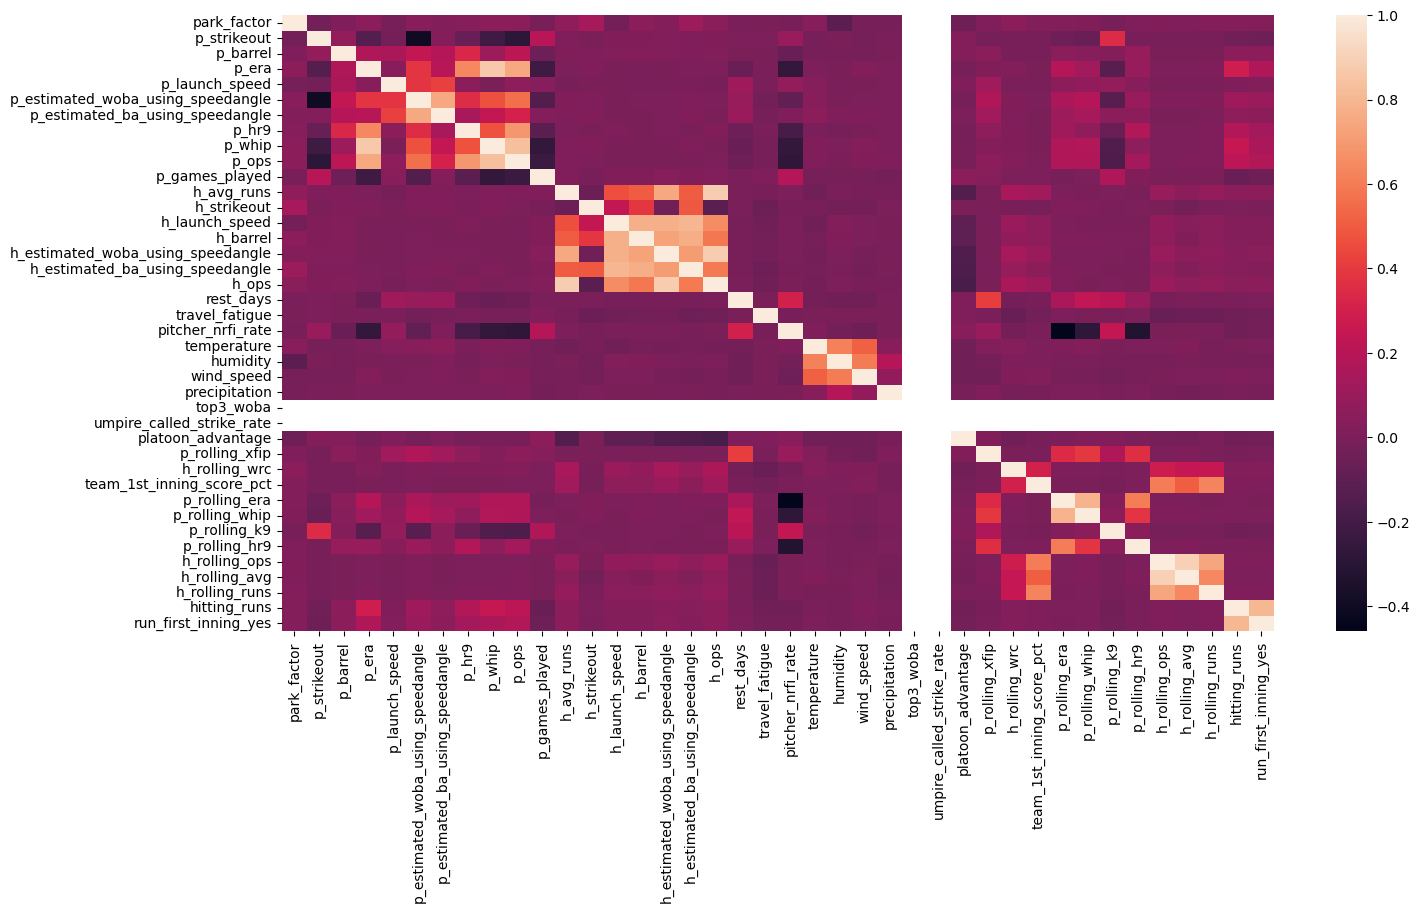

Ridge Reg Mean Squared Error: 0.8360937465289043
Ridge Reg RMSE: 0.9143816197457735
Ridge Reg R Square: 0.06257054779190896
First 10 predictions: [ 0.36567848  0.51789905 -0.00424046  0.71862894  0.50856228  0.3696466
  0.79633708  0.47944629  0.99601742  0.32661671]
Mean runs predicted: 0.5193993363246032
Max runs predicted: 7.493463558350868
Min runs predicted: -0.21387199144414026
Bayes Classifier Accuracy: 0.6917709829673713
True mean of run_first_inning_yes: 0.28629479128186186
XGBoost -- Accuracy: 0.7713142505386272
XGBoost -- Precision: 0.8060213414634146
XGBoost -- Recall: 0.9003831417624522
XGBoost -- F1 score: 0.8505932032978081
Decision Tree Accuracy: 0.6919052016004925
Decision Tree Confusion matrix:
 [[1775  574]
 [ 427  473]]
First 5 predicted probabilities:
 [[1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [1. 0.]]
Random Forest confusion matrix:
 [[2234  115]
 [ 740  160]]
Random Forest accuracy: 0.7368421052631579
Random Forest precision: 0.7511768661735037
Random Forest recall: 0

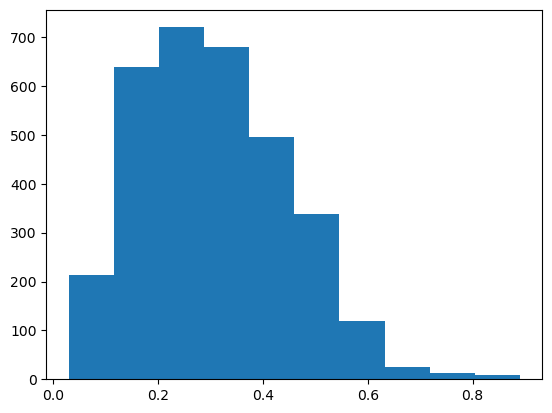

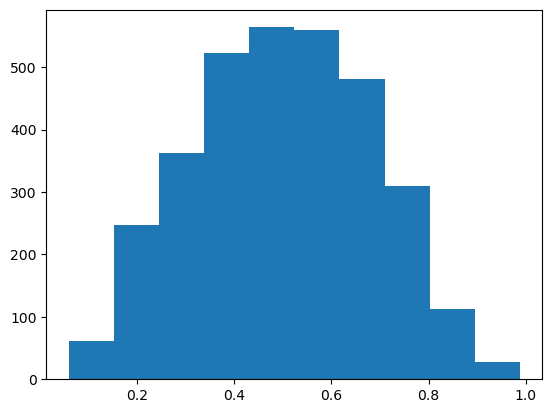

In [27]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.utils import resample
from xgboost import XGBClassifier 
from xgboost import XGBRegressor
from sklearn.isotonic import IsotonicRegression
import math
from scipy.stats import norm
from sklearn.naive_bayes import GaussianNB
import h2o
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
import shap
from sklearn.calibration import calibration_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Force all columns to numeric (column by column)
# ============================================================
print("Converting all columns to numeric...")
model_df = model_df.apply(pd.to_numeric, errors='coerce').fillna(0)
model_df_log = model_df_log.apply(pd.to_numeric, errors='coerce').fillna(0)

# Verify no NaNs remain
assert model_df.isnull().sum().sum() == 0, "Still NaNs in model_df"
assert model_df_log.isnull().sum().sum() == 0, "Still NaNs in model_df_log"
print("All data numeric and NaN-free.")

# ============================================================
# 2. Basic exploration (optional)
# ============================================================
print("Mean of run_first_inning_yes:", 2 * model_df['run_first_inning_yes'].mean())
print("Games with hitting_runs > 0.5:", (model_df['hitting_runs'] > 0.5).sum())
print("Games with hitting_runs < 0.5:", (model_df['hitting_runs'] < 0.5).sum())

plt.figure(figsize=(16, 8))
sns.heatmap(model_df.corr())
plt.show()

# ============================================================
# 3. Ridge regression (predicts runs)
# ============================================================
X = model_df.drop(["hitting_runs", "run_first_inning_yes"], axis=1)
y = model_df["hitting_runs"]
# Add small epsilon to avoid log(0) warnings (not strictly needed for ridge)
y_log = np.log(y + 1e-6)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)
y_pred = ridge_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print("Ridge Reg Mean Squared Error:", mse)
print("Ridge Reg RMSE:", math.sqrt(mse))
r2 = r2_score(y_test, y_pred)
print("Ridge Reg R Square:", r2)
print("First 10 predictions:", y_pred[:10])
print("Mean runs predicted:", y_pred.mean())
print("Max runs predicted:", y_pred.max())
print("Min runs predicted:", y_pred.min())

# ============================================================
# 4. Bayes Classifier (binary)
# ============================================================
X_nb = model_df_log.drop(['run_first_inning_yes', 'hitting_runs'], axis=1)
y_nb = model_df_log['run_first_inning_yes']

X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb, y_nb, test_size=0.3, random_state=42)
nb_clf = GaussianNB()
nb_clf.fit(X_train_nb, y_train_nb)
accuracy = nb_clf.score(X_test_nb, y_test_nb)
print('Bayes Classifier Accuracy:', accuracy)

y_prob = nb_clf.predict_proba(model_df_log.drop(columns=['run_first_inning_yes', 'hitting_runs']))[:, :1]
nb_test_df = model_df_log
print("True mean of run_first_inning_yes:", nb_test_df['run_first_inning_yes'].mean())

# ============================================================
# 5. XGBoost Classifier
# ============================================================
X_train_xg, X_test_xg, y_train_xg, y_test_xg = train_test_split(
    model_df_log.drop(["run_first_inning_yes", "hitting_runs"], axis=1),
    model_df_log["run_first_inning_yes"],
    test_size=0.2, random_state=42
)
xgb_class = XGBClassifier(objective='binary:logistic', reg_lambda=0.001)
xgb_class.fit(X_train_xg, y_train_xg)
xgb_pred = xgb_class.predict(X_test_xg)
cm_xgb = confusion_matrix(y_test_xg, xgb_pred)
acc_xgb = (cm_xgb[0,0] + cm_xgb[1,1]) / np.sum(cm_xgb)
prec_xgb = cm_xgb[0,0] / (cm_xgb[0,0] + cm_xgb[1,0]) if (cm_xgb[0,0] + cm_xgb[1,0]) > 0 else 0
rec_xgb = cm_xgb[0,0] / (cm_xgb[0,0] + cm_xgb[0,1]) if (cm_xgb[0,0] + cm_xgb[0,1]) > 0 else 0
f1_xgb = 2 * (prec_xgb * rec_xgb) / (prec_xgb + rec_xgb) if (prec_xgb + rec_xgb) > 0 else 0
print("XGBoost -- Accuracy:", acc_xgb)
print("XGBoost -- Precision:", prec_xgb)
print("XGBoost -- Recall:", rec_xgb)
print("XGBoost -- F1 score:", f1_xgb)

# ============================================================
# 6. Decision Tree Classifier
# ============================================================
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    model_df_log.drop(["run_first_inning_yes", "hitting_runs"], axis=1),
    model_df_log["run_first_inning_yes"],
    test_size=0.2, random_state=42
)
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train_dt, y_train_dt)
y_pred_dt = dt_clf.predict(X_test_dt)
y_prob_dt = dt_clf.predict_proba(X_test_dt)
acc_dt = accuracy_score(y_test_dt, y_pred_dt)
cm_dt = confusion_matrix(y_test_dt, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)
print("Decision Tree Confusion matrix:\n", cm_dt)
print("First 5 predicted probabilities:\n", y_prob_dt[:5])

# ============================================================
# 7. Random Forest Classifier (binary)
# ============================================================
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    model_df_log.drop(["run_first_inning_yes", "hitting_runs"], axis=1),
    model_df_log["run_first_inning_yes"],
    test_size=0.2, random_state=42
)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)
preds_rf = rf.predict_proba(X_test_rf)[:, 1]
test_preds_rf = rf.predict(X_test_rf)
cm_rf = confusion_matrix(y_test_rf, test_preds_rf)
acc_rf = (cm_rf[0,0] + cm_rf[1,1]) / np.sum(cm_rf)
prec_rf = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[1,0]) if (cm_rf[0,0] + cm_rf[1,0]) > 0 else 0
rec_rf = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[0,1]) if (cm_rf[0,0] + cm_rf[0,1]) > 0 else 0
f1_rf = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf) if (prec_rf + rec_rf) > 0 else 0
print("Random Forest confusion matrix:\n", cm_rf)
print("Random Forest accuracy:", acc_rf)
print("Random Forest precision:", prec_rf)
print("Random Forest recall:", rec_rf)
print("Random Forest f1 score:", f1_rf)
print("Random Forest mean probability:", preds_rf.mean())

plt.hist(preds_rf)
plt.show()
plt.hist(preds_rf + preds_rf - (preds_rf * preds_rf))
plt.show()

Data loaded. model_df shape: (16242, 40)
model_df_log shape: (16242, 40)
First 5 predicted probabilities: [0.26907518 0.32428826 0.23999926 0.23791078 0.26393938]
Confusion matrix:
 [[2347    2]
 [ 883   17]]
Accuracy: 0.7276084949215144
Precision: 0.726625386996904
Recall: 0.9991485738612176
F1 score: 0.8413694210431977
Mean predicted probability: 0.29083170877688425


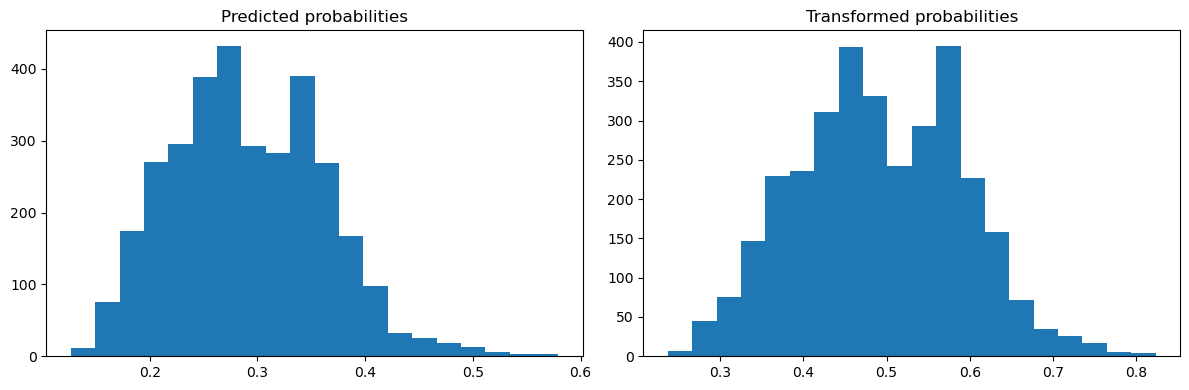

Confusion matrix with threshold 0.292:
 [[1423  926]
 [ 330  570]]
Accuracy with threshold 0.292: 0.613419513696522
SHAP plot skipped (optional).


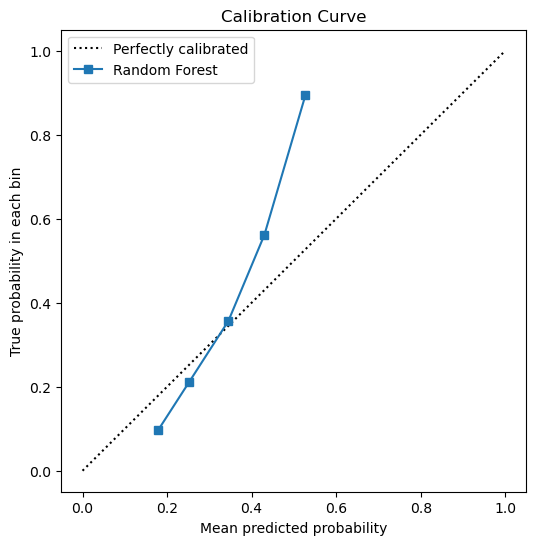

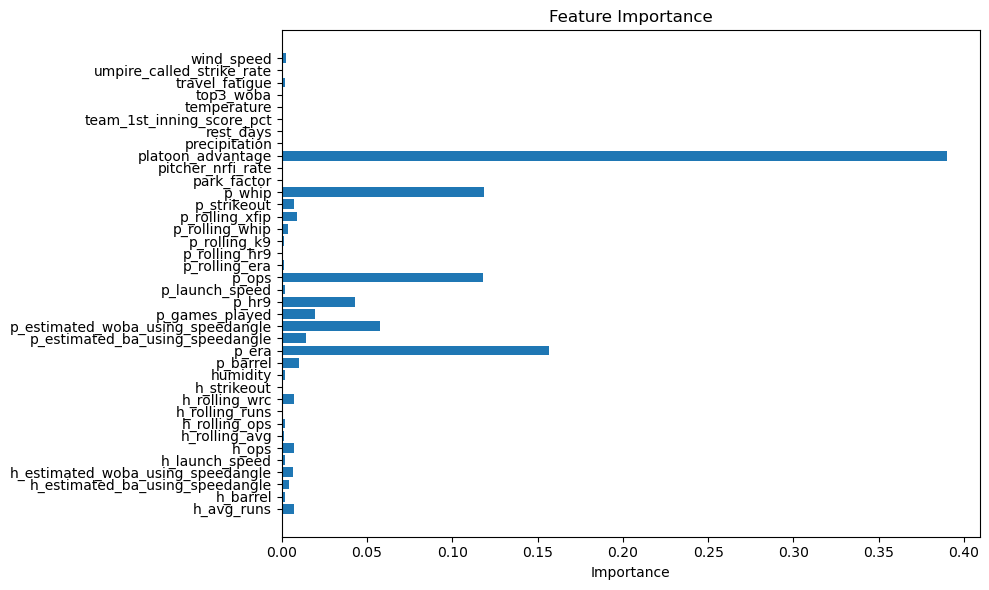

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.calibration import calibration_curve
import shap

# ---------------------------
# 1. Load the saved dataframes
# ---------------------------
model_df = pd.read_csv('model_df.csv')
model_df_log = pd.read_csv('model_df_log.csv')

# Add dummy pred_prob column if any script expects it (not needed for evaluation, but safe)
# model_df['pred_prob'] = 0.0

print("Data loaded. model_df shape:", model_df.shape)
print("model_df_log shape:", model_df_log.shape)

# ---------------------------
# 2. Train/test split (exclude hitting_runs from features)
# ---------------------------
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    model_df_log.drop(["run_first_inning_yes", "hitting_runs"], axis=1),
    model_df_log["run_first_inning_yes"],
    test_size=0.2,
    random_state=42
)

# ---------------------------
# 3. Random Forest with best hyperparameters from tuning
# ---------------------------
forest = RandomForestClassifier(
    bootstrap=False,
    ccp_alpha=0.0,
    class_weight=None,
    criterion='entropy',
    max_depth=6,
    max_leaf_nodes=None,          # <-- fixed: None (not none)
    min_impurity_decrease=0.0,
    min_samples_split=0.15,
    min_weight_fraction_leaf=0.0,
    n_estimators=64,
    n_jobs=1,
    random_state=42,
    warm_start=False
)

forest.fit(X_train_rf, y_train_rf)

# ---------------------------
# 4. Predictions and evaluation
# ---------------------------
predictions_rf = forest.predict_proba(X_test_rf)[:, 1]   # probability of class 1 (NRFI? Actually run in first inning)
test_preds_rf = forest.predict(X_test_rf)

print("First 5 predicted probabilities:", predictions_rf[:5])

cm_rf = confusion_matrix(y_test_rf, test_preds_rf)
print("Confusion matrix:\n", cm_rf)

accuracy_rf = (cm_rf[0,0] + cm_rf[1,1]) / np.sum(cm_rf)
precision_rf = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[1,0]) if (cm_rf[0,0] + cm_rf[1,0]) > 0 else 0
recall_rf = cm_rf[0,0] / (cm_rf[0,0] + cm_rf[0,1]) if (cm_rf[0,0] + cm_rf[0,1]) > 0 else 0
f1_score_rf = 2 * (precision_rf * recall_rf) / (precision_rf + recall_rf) if (precision_rf + recall_rf) > 0 else 0

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1 score:", f1_score_rf)
print("Mean predicted probability:", predictions_rf.mean())

# Histograms
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(predictions_rf, bins=20)
plt.title("Predicted probabilities")
plt.subplot(1,2,2)
plt.hist(predictions_rf + predictions_rf - (predictions_rf * predictions_rf), bins=20)
plt.title("Transformed probabilities")
plt.tight_layout()
plt.show()

# Prepare features for prediction (exclude target and hitting_runs, and any extra columns not used in training)
X_pred = model_df.drop(columns=['hitting_runs', 'run_first_inning_yes'])
# Ensure we only use the same columns as training (optional but safe)
train_cols = X_train_rf.columns
X_pred = X_pred[train_cols]   # this automatically excludes 'pred_prob' if present
random_forest_test = model_df.copy()
random_forest_test['pred_prob'] = forest.predict_proba(X_pred)[:, 1]

# Optional threshold adjustment (0.292 from original)
new_threshold = 0.292
y_prob = forest.predict_proba(X_test_rf)[:, 1]
y_pred_new = (y_prob > new_threshold).astype(int)
new_cm = confusion_matrix(y_test_rf, y_pred_new)
print("Confusion matrix with threshold 0.292:\n", new_cm)
print("Accuracy with threshold 0.292:", accuracy_score(y_test_rf, y_pred_new))

# SHAP disabled – not essential
print("SHAP plot skipped (optional).")
# Calibration curve
true_prob, pred_prob1 = calibration_curve(y_test_rf, predictions_rf, n_bins=10)
plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1], 'k:', label="Perfectly calibrated")
plt.plot(pred_prob1, true_prob, 's-', label="Random Forest")
plt.xlabel("Mean predicted probability")
plt.ylabel("True probability in each bin")
plt.title("Calibration Curve")
plt.legend()
plt.show()

# Feature importance
importances = forest.feature_importances_
feature_names = X_train_rf.columns
plt.figure(figsize=(10,6))
plt.barh(range(len(importances)), importances)
plt.yticks(range(len(importances)), feature_names)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

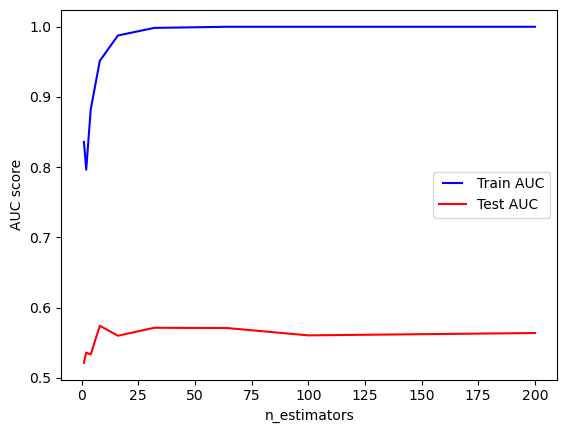

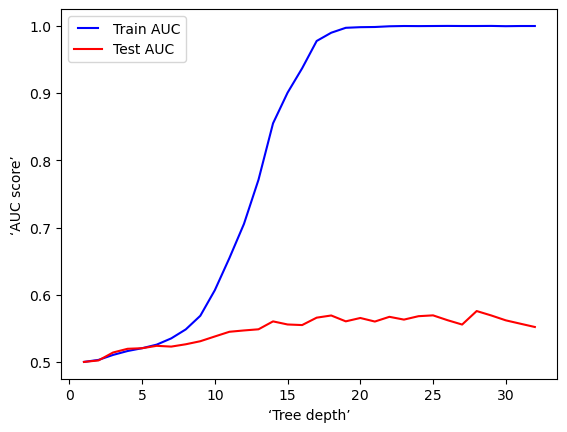

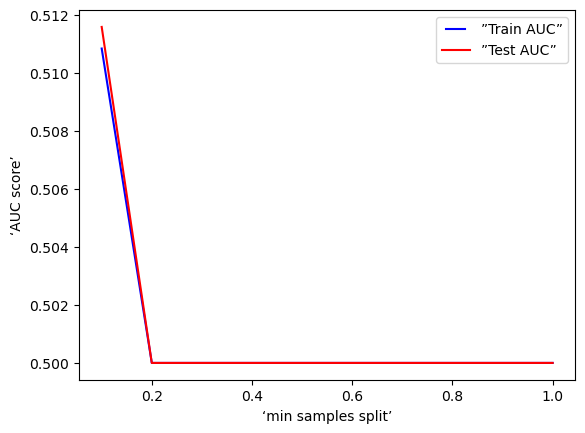

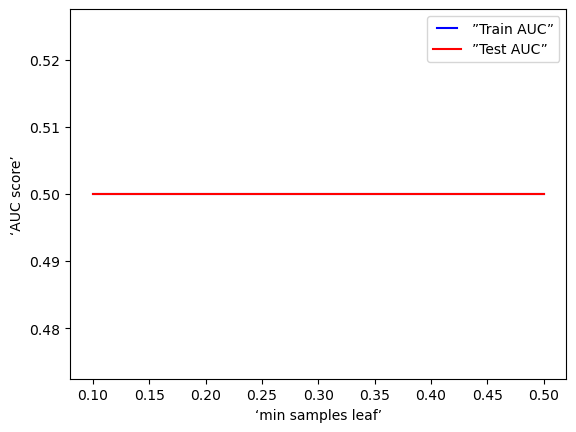

Fitting 5 folds for each of 576 candidates, totalling 2880 fits
Best hyperparameters:  {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': 6, 'max_leaf_nodes': 20, 'min_impurity_decrease': 0.0, 'min_samples_split': 0.15, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 64, 'n_jobs': 1, 'random_state': 42, 'warm_start': False}
Best score:  0.5080677080626242


In [29]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import joblib
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier 
from xgboost import XGBRegressor
from sklearn.isotonic import IsotonicRegression
import math
from scipy.stats import norm
from sklearn.naive_bayes import GaussianNB
import h2o
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
import shap
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc
import sklearn
from sklearn.metrics import make_scorer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
##
# Split data for Random Forest tuning
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    model_df_log.drop(["run_first_inning_yes", "hitting_runs"], axis=1),
    model_df_log["run_first_inning_yes"],
    test_size=0.2,
    random_state=42
)
# n_estimators
n_estimators = [1, 2, 4, 8, 16, 32, 64, 100, 200]
train_results = []
test_results = []
for estimator in n_estimators:
    rf = RandomForestClassifier(n_estimators=estimator, n_jobs=-1)
    rf.fit(X_train_rf, y_train_rf)
    train_pred = rf.predict(X_train_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train_rf, train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    train_results.append(roc_auc)
    y_pred = rf.predict(X_test_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test_rf, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(n_estimators, train_results, 'b', label='Train AUC')
line2, = plt.plot(n_estimators, test_results, 'r', label='Test AUC')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('AUC score')
plt.xlabel('n_estimators')
plt.show()

#n_estimators = 64

# max_depths
max_depths = range(1, 33)   # generates integers 1 through 32
train_results = []
test_results = []
for max_depth in max_depths:
    rf = RandomForestClassifier(max_depth=max_depth, n_estimators = 64, n_jobs=-1)
    rf.fit(X_train_rf, y_train_rf)
    train_pred = rf.predict(X_train_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train_rf, train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    train_results.append(roc_auc)
    y_pred = rf.predict(X_test_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test_rf, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(max_depths, train_results, 'b', label='Train AUC')
line2, = plt.plot(max_depths, test_results, 'r', label='Test AUC')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('‘AUC score’')
plt.xlabel('‘Tree depth’')
plt.show()

#max_depths = 6

# min_samples_splits
min_samples_splits = np.linspace(0.1, 1.0, 10, endpoint=True)
train_results = []
test_results = []
for min_samples_split in min_samples_splits:
    rf = RandomForestClassifier(min_samples_split=min_samples_split, n_jobs=-1)
    rf.fit(X_train_rf, y_train_rf)
    train_pred = rf.predict(X_train_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train_rf, train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    train_results.append(roc_auc)
    y_pred = rf.predict(X_test_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test_rf, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(min_samples_splits, train_results, 'b', label='”Train AUC”')
line2, = plt.plot(min_samples_splits, test_results, 'r', label='”Test AUC”')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('‘AUC score’')
plt.xlabel('‘min samples split’')
plt.show()
#min_samples_split = .15

# min_samples_leafs
min_samples_leafs = np.linspace(0.1, 0.5, 5, endpoint=True)
train_results = []
test_results = []
for min_samples_leaf in min_samples_leafs:
    rf = RandomForestClassifier(min_samples_leaf=min_samples_leaf, min_samples_split=.15, n_estimators = 64, n_jobs=-1)
    rf.fit(X_train_rf, y_train_rf)
    train_pred = rf.predict(X_train_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_train_rf, train_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    train_results.append(roc_auc)
    y_pred = rf.predict(X_test_rf)
    false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test_rf, y_pred)
    roc_auc = auc(false_positive_rate, true_positive_rate)
    test_results.append(roc_auc)
from matplotlib.legend_handler import HandlerLine2D
line1, = plt.plot(min_samples_leafs, train_results, 'b', label='”Train AUC”')
line2, = plt.plot(min_samples_leafs, test_results, 'r', label='”Test AUC”')
plt.legend(handler_map={line1: HandlerLine2D(numpoints=2)})
plt.ylabel('‘AUC score’')
plt.xlabel('‘min samples leaf’')
plt.show()

#delete min_samples_leaf

# GRID SEARCH
param_grid = {
    'n_estimators': [64],
    'criterion': ['entropy'],
    'max_depth': [6],
    'min_samples_split': [.15],
    'min_weight_fraction_leaf': [0.0, 0.1, 0.2],
    'max_leaf_nodes': [None, 10, 20, 30],
    'min_impurity_decrease': [0.0, 0.01, 0.05],
    #'min_impurity_split': [None, 0.1, 0.2],
    'bootstrap': [True, False],
    'n_jobs': [1],
    'random_state': [42],
    'warm_start': [False, True],
    'ccp_alpha': [0.0,0.5,1,3],
    'class_weight': [None]
}

rfc = RandomForestClassifier()
grid_search = GridSearchCV(
    rfc, param_grid, cv=5, n_jobs=-1, verbose=1, scoring='balanced_accuracy')

grid_search.fit(X_train_rf, y_train_rf)

print("Best hyperparameters: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

In [30]:
# Save model and lookup tables for future predictions
import joblib

# Determine which model to save
if 'grid_search' in globals() and grid_search is not None:
    best_model = grid_search.best_estimator_
    print("Saving best model from GridSearchCV")
elif 'forest' in globals() and forest is not None:
    best_model = forest
    print("Saving manually trained RandomForest")
else:
    raise NameError("No trained model found (neither grid_search nor forest).")

# Save the model
joblib.dump(best_model, 'nrfi_best_model.pkl')
print("Model saved as 'nrfi_best_model.pkl'")

# Save lookup tables (these should exist after Cell 8)
pitchers1.to_csv('pitchers1_latest.csv', index=False)
hitters1.to_csv('hitters1_latest.csv', index=False)
pf.to_csv('park_factors_latest.csv', index=False)
print("Lookup tables saved.")

Saving best model from GridSearchCV
Model saved as 'nrfi_best_model.pkl'
Lookup tables saved.


In [45]:
# -------------------------------------------------------------------
# Complete NRFI Prediction Script (with accent normalization)
# -------------------------------------------------------------------

import pandas as pd
import numpy as np
import joblib
import unicodedata
from datetime import date

# -------------------------------
# Helper: Normalize names (remove accents, lower case)
# -------------------------------
def normalize_name(name):
    """Remove accents and convert to lower case."""
    name = unicodedata.normalize('NFKD', name).encode('ASCII', 'ignore').decode('utf-8')
    return name.lower()

# -------------------------------
# Load model and lookup tables
# -------------------------------
model = joblib.load('nrfi_best_model.pkl')
print(f"Model loaded. Expected features: {len(model.feature_names_in_)}")

# Load lookup tables (adjust filenames as needed)
pitchers1 = pd.read_csv('pitchers1_latest.csv')
hitters1 = pd.read_csv('hitters1_latest.csv')
pf = pd.read_csv('park_factors_latest.csv')

# Add normalized name column for pitchers (once)
pitchers1['norm_name'] = pitchers1['player_name'].apply(normalize_name)

# Team abbreviation mapping (adjust based on your data)
team_name_map = {
    'CHW': 'CWS', 'CWS': 'CWS',
    'SFG': 'SF', 'SDP': 'SD', 'TBR': 'TB', 'WSN': 'WSH',
    # Add others if needed
}

# -------------------------------
# Helper: Get pitcher row (with fallback)
# -------------------------------
def get_pitcher_row(pitcher_name, pitchers_df):
    search_name = normalize_name(pitcher_name)
    match = pitchers_df[pitchers_df['norm_name'] == search_name]
    if match.empty:
        # Try partial match on last name (split by comma or space)
        last_name = search_name.split(',')[0].strip()
        match = pitchers_df[pitchers_df['norm_name'].str.contains(last_name, na=False)]
    if match.empty:
        print(f"\n⚠️ Pitcher '{pitcher_name}' not found in lookup table.")
        print("Using league average stats. Prediction will be less accurate.\n")
        # Return a Series with mean of all numeric columns (preserve column names)
        avg = pitchers_df.mean(numeric_only=True)
        return avg
    return match.iloc[0]

# -------------------------------
# Helper: Get team row (with fallback)
# -------------------------------
def get_team_row(team_abbr, hitters_df):
    team_abbr = team_name_map.get(team_abbr.upper(), team_abbr.upper())
    match = hitters_df[hitters_df['hitting_team'] == team_abbr]
    if match.empty:
        print(f"\n⚠️ Team '{team_abbr}' not found in lookup table.")
        print("Using league average stats. Prediction will be less accurate.\n")
        avg = hitters_df.mean(numeric_only=True)
        return avg
    return match.iloc[0]

# -------------------------------
# User input
# -------------------------------
print("Enter game details:")
away_team = input("Away team (3-letter code): ").upper()
home_team = input("Home team (3-letter code): ").upper()
away_pitcher = input("Away starting pitcher (Last, First): ")
home_pitcher = input("Home starting pitcher (Last, First): ")
game_date_str = input("Game date (YYYY-MM-DD) [Enter for today]: ")
if not game_date_str:
    game_date_str = date.today().strftime('%Y-%m-%d')

# -------------------------------
# Fetch data for the game
# -------------------------------
away_p = get_pitcher_row(away_pitcher, pitchers1)
home_p = get_pitcher_row(home_pitcher, pitchers1)
away_h = get_team_row(away_team, hitters1)
home_h = get_team_row(home_team, hitters1)

# Park factor
pf_row = pf[pf['home_team'] == home_team]
park_factor = pf_row['park_factor'].values[0] if not pf_row.empty else 100.0

# Defaults for features not in lookup tables (weather, umpire, etc.)
defaults = {
    'rest_days': 5,
    'travel_fatigue': 0,
    'temperature': 70,
    'humidity': 50,
    'wind_speed': 5,
    'precipitation': 0,
    'umpire_called_strike_rate': 0.630,
    'time_through_order': 1,
    'team_1st_inning_score_pct': 0.286,
    'top3_woba': 0.300,
}

# -------------------------------
# Build feature vectors for top and bottom of first inning
# -------------------------------
top_dict = {}
bottom_dict = {}

for col in model.feature_names_in_:
    # Top of first: away batting, home pitching
    if col in home_p.index:
        top_dict[col] = home_p[col]
    elif col in away_h.index:
        top_dict[col] = away_h[col]
    elif col == 'park_factor':
        top_dict[col] = park_factor
    elif col in defaults:
        top_dict[col] = defaults[col]
    else:
        top_dict[col] = 0

    # Bottom of first: home batting, away pitching
    if col in away_p.index:
        bottom_dict[col] = away_p[col]
    elif col in home_h.index:
        bottom_dict[col] = home_h[col]
    elif col == 'park_factor':
        bottom_dict[col] = park_factor
    elif col in defaults:
        bottom_dict[col] = defaults[col]
    else:
        bottom_dict[col] = 0

# Convert to DataFrames with correct column order
top_df = pd.DataFrame([top_dict])[model.feature_names_in_]
bottom_df = pd.DataFrame([bottom_dict])[model.feature_names_in_]

# Predict probabilities (class 1 = run in that half-inning)
prob_top = model.predict_proba(top_df)[0][1]
prob_bottom = model.predict_proba(bottom_df)[0][1]
nrfi_prob = 1 - (prob_top + prob_bottom - prob_top * prob_bottom)

# -------------------------------
# Output results
# -------------------------------
print("\n" + "="*50)
print(f"Prediction for {away_team} @ {home_team} on {game_date_str}")
print(f"Top 1st (away batting) run probability: {prob_top:.3f}")
print(f"Bottom 1st (home batting) run probability: {prob_bottom:.3f}")
print(f"NRFI probability: {nrfi_prob:.3f}")
print("="*50)

Model loaded. Expected features: 38
Enter game details:


Away team (3-letter code):  NYM
Home team (3-letter code):  LAD
Away starting pitcher (Last, First):  McLean, Nolan
Home starting pitcher (Last, First):  Yamamoto, Yoshinobu
Game date (YYYY-MM-DD) [Enter for today]:  



Prediction for NYM @ LAD on 2026-04-14
Top 1st (away batting) run probability: 0.282
Bottom 1st (home batting) run probability: 0.239
NRFI probability: 0.546


In [39]:
print(sorted(hitters1['hitting_team'].unique()))

['ATH', 'ATL', 'AZ', 'BAL', 'BOS', 'CHC', 'CIN', 'CLE', 'COL', 'CWS', 'DET', 'HOU', 'KC', 'LAA', 'LAD', 'MIA', 'MIL', 'MIN', 'NYM', 'NYY', 'PHI', 'PIT', 'SD', 'SEA', 'SF', 'STL', 'TB', 'TEX', 'TOR', 'WSH']
